In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from random import randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta
from math import sqrt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history, create_loss_csv

In [46]:
file_path = '../datasets/Simulate_Cleaned_Merged/Station3_simulated_cleaned_merged_data.csv'
data = load_data(3)
full_data = data.copy()
#Set to Datetime
#data['Date'] = pd.to_datetime(data['Date'])
data = preprocess(data)
data.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,0.00,0.158,0.247,0.271,0.332,5.18,6.43,8.50,12.78,0.000,-0.547,83.0,0.02,0.476356,0.455375,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.00,0.158,0.246,0.271,0.332,5.06,6.33,8.43,12.77,0.000,-0.440,81.6,0.20,0.257154,0.618686,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.00,0.157,0.246,0.270,0.332,5.00,6.24,8.35,12.73,0.000,-0.175,80.5,0.20,0.317979,0.498167,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.00,0.157,0.246,0.270,0.332,4.97,6.16,8.29,12.70,0.000,-0.047,80.8,0.17,0.153881,0.710528,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.25,0.157,0.246,0.270,0.332,4.93,6.11,8.22,12.67,0.254,-0.074,88.7,0.01,0.230480,0.223428,8.660254e-01,0.500000,0.004372,0.999990


#Feature Engineering

Create different windows for sum of past precipitation values to help engineer the prediction percentages of rain. Chosen windows are 1hr, 2hr,5hr, 10hr, and 24hr. After creating windows, shift 1 level back so they are not including the current rain therefore are past window sums. Then use sums to equal predicted rain given x amount of hours.

In [47]:
na_counts = data.isna().sum()
print("NA counts per column:")
print(na_counts)

NA counts per column:
Ppt         0
SWC_5       0
SWC_10      0
SWC_20      0
SWC_50      0
T_5         0
T_10        0
T_20        0
T_50        0
Ppt.1       0
Tair        0
RH          0
Srad        0
Wx          0
Wy          0
Day sin     0
Day cos     0
Year sin    0
Year cos    0
dtype: int64


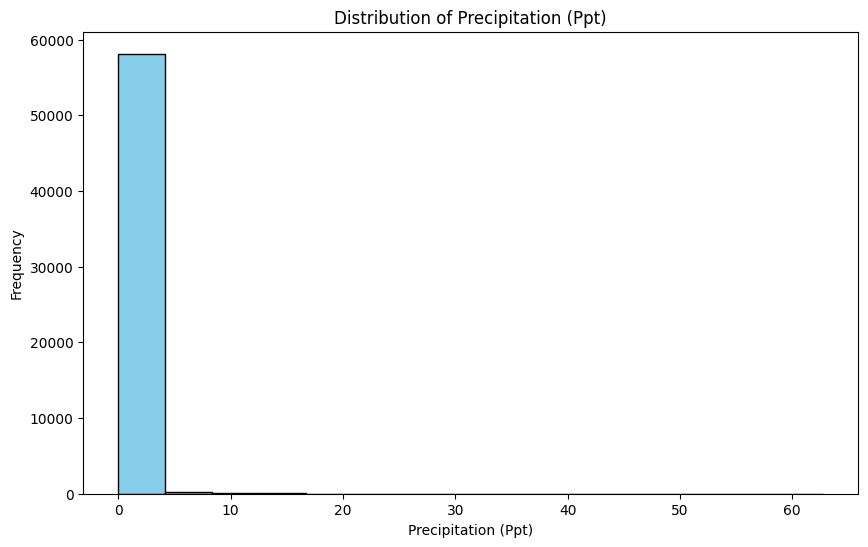

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(data['Ppt'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Precipitation (Ppt)')
plt.xlabel('Precipitation (Ppt)')
plt.ylabel('Frequency')
plt.show()

In [49]:
days = 1
data['Sum_Rain_1h'] = data['Ppt'].rolling(window=1, min_periods=1).sum()
data['Sum_Rain_3h'] = data['Ppt'].rolling(window=3, min_periods=1).sum()
data['Sum_Rain_6h'] = data['Ppt'].rolling(window=6, min_periods=1).sum()
data['Sum_Rain_12h'] = data['Ppt'].rolling(window=12, min_periods=1).sum()
data['Sum_Rain_24h'] = data['Ppt'].rolling(window=24 * days, min_periods=1).sum()
data.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,...,Wy,Day sin,Day cos,Year sin,Year cos,Sum_Rain_1h,Sum_Rain_3h,Sum_Rain_6h,Sum_Rain_12h,Sum_Rain_24h
2015-01-01 00:00:00,0.00,0.158,0.247,0.271,0.332,5.18,6.43,8.50,12.78,0.000,...,0.455375,1.232357e-12,1.000000,0.001505,0.999999,0.00,0.00,0.00,0.00,0.00
2015-01-01 01:00:00,0.00,0.158,0.246,0.271,0.332,5.06,6.33,8.43,12.77,0.000,...,0.618686,2.588190e-01,0.965926,0.002222,0.999998,0.00,0.00,0.00,0.00,0.00
2015-01-01 02:00:00,0.00,0.157,0.246,0.270,0.332,5.00,6.24,8.35,12.73,0.000,...,0.498167,5.000000e-01,0.866025,0.002939,0.999996,0.00,0.00,0.00,0.00,0.00
2015-01-01 03:00:00,0.00,0.157,0.246,0.270,0.332,4.97,6.16,8.29,12.70,0.000,...,0.710528,7.071068e-01,0.707107,0.003656,0.999993,0.00,0.00,0.00,0.00,0.00
2015-01-01 04:00:00,0.25,0.157,0.246,0.270,0.332,4.93,6.11,8.22,12.67,0.254,...,0.223428,8.660254e-01,0.500000,0.004372,0.999990,0.25,0.25,0.25,0.25,0.25


In [50]:
#Shift data by 1 to not include current rain in window
data['Sum_Rain_1h_Shifted'] = data['Sum_Rain_1h'].shift(1)
data['Sum_Rain_3h_Shifted'] = data['Sum_Rain_3h'].shift(1)
data['Sum_Rain_6h_Shifted'] = data['Sum_Rain_6h'].shift(1)
data['Sum_Rain_12h_Shifted'] = data['Sum_Rain_12h'].shift(1)
data['Sum_Rain_24h_Shifted'] = data['Sum_Rain_24h'].shift(1)
data.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,...,Sum_Rain_1h,Sum_Rain_3h,Sum_Rain_6h,Sum_Rain_12h,Sum_Rain_24h,Sum_Rain_1h_Shifted,Sum_Rain_3h_Shifted,Sum_Rain_6h_Shifted,Sum_Rain_12h_Shifted,Sum_Rain_24h_Shifted
2015-01-01 00:00:00,0.00,0.158,0.247,0.271,0.332,5.18,6.43,8.50,12.78,0.000,...,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00,0.00,0.158,0.246,0.271,0.332,5.06,6.33,8.43,12.77,0.000,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00,0.00,0.157,0.246,0.270,0.332,5.00,6.24,8.35,12.73,0.000,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00,0.00,0.157,0.246,0.270,0.332,4.97,6.16,8.29,12.70,0.000,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
2015-01-01 04:00:00,0.25,0.157,0.246,0.270,0.332,4.93,6.11,8.22,12.67,0.254,...,0.25,0.25,0.25,0.25,0.25,0.0,0.0,0.0,0.0,0.0


In [51]:
#Actual rain for prediction
data['Actual_Rain_Next_Hour'] = data['Ppt'].shift(-1)
#Set predicted rain to the sum of shifted rain
data['Predicted_Rain_Next_Hour_1h'] = data['Sum_Rain_1h_Shifted']
data['Predicted_Rain_Next_Hour_3h'] = data['Sum_Rain_3h_Shifted']
data['Predicted_Rain_Next_Hour_6h'] = data['Sum_Rain_6h_Shifted']
data['Predicted_Rain_Next_Hour_12h'] = data['Sum_Rain_12h_Shifted']
data['Predicted_Rain_Next_Hour_24h'] = data['Sum_Rain_24h_Shifted']
data.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,...,Sum_Rain_3h_Shifted,Sum_Rain_6h_Shifted,Sum_Rain_12h_Shifted,Sum_Rain_24h_Shifted,Actual_Rain_Next_Hour,Predicted_Rain_Next_Hour_1h,Predicted_Rain_Next_Hour_3h,Predicted_Rain_Next_Hour_6h,Predicted_Rain_Next_Hour_12h,Predicted_Rain_Next_Hour_24h
2015-01-01 00:00:00,0.00,0.158,0.247,0.271,0.332,5.18,6.43,8.50,12.78,0.000,...,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00,0.00,0.158,0.246,0.271,0.332,5.06,6.33,8.43,12.77,0.000,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00,0.00,0.157,0.246,0.270,0.332,5.00,6.24,8.35,12.73,0.000,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00,0.00,0.157,0.246,0.270,0.332,4.97,6.16,8.29,12.70,0.000,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
2015-01-01 04:00:00,0.25,0.157,0.246,0.270,0.332,4.93,6.11,8.22,12.67,0.254,...,0.0,0.0,0.0,0.0,0.51,0.0,0.0,0.0,0.0,0.0


In [52]:
#Cutoff first 48hours of data
cutoff_date = data.index.min() + pd.Timedelta(days=2)
data = data[data.index >= cutoff_date]

In [53]:
def rainfall_to_percentage(rainfall_amounts):
    # Define the thresholds for different categories of rainfall
    thresholds = {
        'no_rain': (0.0, 0.0),
        'very_light': (0.0, 0.1),
        'light_rain': (0.1, 0.7),
        'moderate': (0.7, 1.0),
        'heavy': (1.0, 2.0),
        'very_heavy': (2.0, 4.0),
        'severe': (4.0, 6.0),
        'extreme': (6.0, float('inf')),
    }

    # Define the percentage chance for each category
    percentages = {
        'no_rain': 3,   # 3% chance if no rain
        'very_light': 5,  # 5% chance for very light rain
        'light_rain': 10,  # 10% chance for light rain
        'moderate': 30,  # 30% chance for moderate rain
        'heavy': 50,  # 50% chance for heavy rain
        'very_heavy': 60,  # 60% chance for very heavy rain
        'severe': 80,  # 80% chance for severe rain
        'extreme': 100,  # 100% chance for extreme rain conditions
    }

    # Convert rainfall amounts to percentages based on the thresholds
    rainfall_percentages = []
    for amount in rainfall_amounts:
        for category, (lower_bound, upper_bound) in thresholds.items():
            if lower_bound < amount <= upper_bound:
                rainfall_percentages.append(percentages[category])
                break
        # If the amount is exactly 0, we categorize it as 'no_rain'
        if amount == 0:
            rainfall_percentages.append(percentages['no_rain'])

    return rainfall_percentages


In [54]:
full_data = data.copy()

In [ ]:
 #data = data.copy().iloc[:-16]

In [ ]:

#data.index = pd.to_datetime(data.index)

# Forecast the trend component
#trend_model = ExponentialSmoothing(decomposition.trend.dropna(), trend='add', seasonal=None, initialization_method="estimated").fit()

# Forecast future values
#num_forecast_steps = 24  # for example, the next 24 hours
#forecasted_trend = trend_model.forecast(steps=num_forecast_steps)

# Predict the seasonal component for the next 24 hours
#seasonal_component = decomposition.seasonal[-24:]

# Combine the trend forecast with the seasonal prediction
#predicted_rainfall = forecasted_trend.values + seasonal_component.values

# Convert the predicted rainfall to percentages
#predicted_rainfall_percentages = rainfall_to_percentage(predicted_rainfall)

In [ ]:
#future_hours = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=16, freq='H')

# Create a DataFrame for the predicted percentages with the future_hours as the index
#forecast_df = pd.DataFrame(data=predicted_rainfall_percentages, index=future_hours, columns=['predicted_rain_percentage'])

In [ ]:
#data_with_forecast = pd.concat([data, forecast_df])

In [ ]:
#data_with_forecast['predicted_rain_percentage'].tail(10)

In [ ]:
'''last_16_hours_actual = full_data['Ppt'].iloc[-26:]
last_16_hours_predicted = forecast_df['predicted_rain_percentage']

# Setting up the plot
plt.figure(figsize=(10, 6))

# Plotting the actual ppt data
plt.plot(last_16_hours_actual.index, last_16_hours_actual, label='Actual Ppt', color='blue', marker='o', linestyle='--')

# Plotting the predicted rain percentage
plt.plot(last_16_hours_actual.index, last_16_hours_predicted, label='Predicted Rain Percentage', color='red', marker='x', linestyle='--')

# Setting labels and title
plt.xlabel('Time')
plt.ylabel('Ppt and Predicted Rain Percentage')
plt.title('Comparison of Actual Ppt and Predicted Rain Percentage for Last 16 Hours')
plt.xticks(rotation=45)
plt.legend()

plt.show()'''

"last_16_hours_actual = full_data['Ppt'].iloc[-26:]\nlast_16_hours_predicted = forecast_df['predicted_rain_percentage']\n\n# Setting up the plot\nplt.figure(figsize=(10, 6))\n\n# Plotting the actual ppt data\nplt.plot(last_16_hours_actual.index, last_16_hours_actual, label='Actual Ppt', color='blue', marker='o', linestyle='--')\n\n# Plotting the predicted rain percentage\nplt.plot(last_16_hours_actual.index, last_16_hours_predicted, label='Predicted Rain Percentage', color='red', marker='x', linestyle='--')\n\n# Setting labels and title\nplt.xlabel('Time')\nplt.ylabel('Ppt and Predicted Rain Percentage')\nplt.title('Comparison of Actual Ppt and Predicted Rain Percentage for Last 16 Hours')\nplt.xticks(rotation=45)\nplt.legend()\n\nplt.show()"

# Scaling and rain calculation methods

columns_to_scale: Created to scale values to range 0-1

calculate_rain_chance: Used to calculate the actual rain chance of a given hour of precipitation in mm. Creates different ranges coresponding to percentage of rain going off of different ranges from research online.

calculate_rain_chance_withsum: The prediction rain chance method, given the different sums of past rainfall for 1hr, 2hhr,5hr,10hr,24hr creates different scenarios and adds or subtracts rain percentages value given the values of different sums.

calculate_rain_chance_withsum_extended: The prediction rain chance method, given the different sums of past rainfall for 1hr, 2hhr,5hr,10hr,24hr creates different scenarios and adds or subtracts rain percentages value given the values of different sums with more cases.

calculate_daily_scaling_factors: Create the different scaling factors for the upcoming predictions using the base value for days 1-7 into the future

calculate_combined_rain_chance: Using scale factors multiplied by base value of 1 hour prediction into the future return the percentages for prediction values.

In [55]:
def calculate_rain_chance(ppt):
    # Expanded thresholds for finer granularity
    if ppt == 0:
        return 3  # 2% chance if no rain
    elif 0 < ppt <= 0.1:
        return 5  # 4% chance for very minimal rain
    elif 0.1 < ppt <= 0.2:
        return 8  # 5% chance
    elif 0.2 < ppt <= 0.3:
        return 10  # 6% chance
    elif 0.3 < ppt <= 0.5:
        return 15  # 10% chance for light rain
    elif 0.5 < ppt <= 0.7:
        return 20  # 20% chance
    elif 0.7 < ppt <= 1.0:
        return 30  # 30% chance for moderate rain
    elif 1.0 < ppt <= 1.5:
        return 40  # 40% chance
    elif 1.5 < ppt <= 2.0:
        return 50  # 50% chance for heavy rain
    elif 2.0 < ppt <= 3.0:
        return 60  # 60% chance
    elif 3.0 < ppt <= 4.0:
        return 70  # 70% chance for very heavy rain
    elif 4.0 < ppt <= 5.0:
        return 80  # 80% chance
    elif 5.0 < ppt <= 6.0:
        return 90  # 90% chance
    else:
        return 100  # 100% chance for extreme rain conditions


In [56]:
def calculate_rain_chance_withsum(sum_1h, sum_3h, sum_6h, sum_12h, sum_24h, timestamp):
    rain_chance = randint(0, 10)# Initialize the rain chance percentage
    month = timestamp.month
    is_spring = month in [3, 4, 5]  # March to May
    is_summer = month in [6, 7, 8]  # June to August
    # Base increase for any rain in the last hour
    if is_spring:
       rain_chance += 25
    elif is_summer:
       rain_chance -= 25
       
    if sum_1h > 0 and sum_1h < 0.3:
      rain_chance += 10
    elif sum_1h > 0.3 and sum_1h < 0.6:
      rain_chance += 20
    elif sum_1h > 0:
        rain_chance += sum_1h * 10  # Increase proportional to amount in the last hour

    # Additional adjustments based on rain over 2 hours and 5 hours
    if sum_3h > sum_1h:
        rain_chance += (sum_3h - sum_1h) * 20  # Weighted increase for additional rain in the last 2 hours
    if sum_6h > sum_3h:
        rain_chance += (sum_6h - sum_3h) * 10  # Further increase for rain over the last 5 hours

    # Consider recent dry period with rain further back
    if sum_12h > sum_6h and sum_1h == 0:
        rain_chance -= 5  # Decrease if recent dry period but rain 10 hours ago
    if sum_24h > sum_12h and sum_1h == 0 and sum_6h <= sum_3h:
        rain_chance -= 10  # Additional decrease for dry recent hours but rain 24 hours ago
    if sum_12h == 0:
      rain_chance -= 10
    elif sum_24h == 0:
      rain_chance -= 15


    # Special conditions for very recent versus older rainfall
    if sum_1h == 0 and sum_12h > 0.01:
        rain_chance += 10  # Slight increase for rain 10 hours ago with recent dryness
    if sum_24h > 0 and sum_12h == 0:
        rain_chance += 5  # Minimal increase for rain 24 hours ago without more recent rain

    if sum_1h > 1 and sum_3h > 2:
        rain_chance += 10  # Bonus increase for significant recent rain
    elif sum_6h > 3 and sum_12h > 5:
        rain_chance += 5  # Moderate bonus for extended rain period

    if sum_24h >= 5:  # Threshold for considering "significant" rain might vary
        rain_chance += 50

    # Ensure the chance does not fall below 1% or exceed 100%
    rain_chance = max(1, min(100, rain_chance))

    return rain_chance


In [57]:
def calculate_rain_chance_extended(sum_1h, sum_3h, sum_6h, sum_12h, sum_24h, days_in_future):
    rain_chance = 20  # Initialize the rain chance percentage

    # Gradual increase for rain in the last hour
    if sum_1h > 0:
        rain_chance += sum_1h * 0.5  # Increase proportional to amount in the last hour

    # Additional adjustments based on rain over 2 hours and 5 hours
    if sum_3h > sum_1h:
        rain_chance += (sum_3h - sum_1h) * 0.2  # Weighted increase for additional rain in the last 2 hours
    if sum_6h > sum_3h:
        rain_chance += (sum_6h - sum_3h) * 0.1  # Further increase for rain over the last 5 hours

    # Consider recent dry period with rain further back
    if sum_12h > sum_6h and sum_1h == 0:
        rain_chance -= 1  # Decrease if recent dry period but rain 10 hours ago
    if sum_24h > sum_12h and sum_1h == 0 and sum_6h <= sum_3h:
        rain_chance -= 1.5  # Additional decrease for dry recent hours but rain 24 hours ago

    # Special conditions for very recent versus older rainfall
    if sum_1h == 0 and sum_12h > 0.01:
        rain_chance += 0.5  # Slight increase for rain 10 hours ago with recent dryness
    if sum_24h > 0 and sum_12h == 0:
        rain_chance += 0.2  # Minimal increase for rain 24 hours ago without more recent rain

    # Bonus increases for significant rain periods
    if sum_1h > 1 and sum_3h > 2:
        rain_chance += 1  # Bonus increase for significant recent rain
    elif sum_6h > 3 and sum_12h > 5:
        rain_chance += 0.5  # Moderate bonus for extended rain period

    # Adjust for days in the future
    if days_in_future > 1:
        # Calculate the probability of rain in the previous 24 hours
        prev_24h_rain_chance = calculate_rain_chance_extended(sum_24h, sum_12h, sum_6h, sum_3h, sum_1h, 1)

        # Add the difference between the previous and current rain chances

        if rain_chance - prev_24h_rain_chance == 0:
            rain_chance += prev_24h_rain_chance * (1 / days_in_future)
        else:
            rain_chance += rain_chance - prev_24h_rain_chance

        for i in range(2, days_in_future):
            prev_24h_rain_chance = calculate_rain_chance_extended(sum_24h, sum_12h, sum_6h, sum_3h, sum_1h, i)
            rain_chance += rain_chance - prev_24h_rain_chance

    # Ensure the chance does not fall below 1% or exceed 100%
    rain_chance = max(1, min(100, rain_chance))

    return rain_chance

In [58]:
data['Rain_Chance_Percentage_1d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    1), axis=1)

data['Rain_Chance_Percentage_2d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    2), axis=1)

data['Rain_Chance_Percentage_3d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    3), axis=1)

data['Rain_Chance_Percentage_4d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    4), axis=1)

data['Rain_Chance_Percentage_5d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    5), axis=1)

data['Rain_Chance_Percentage_6d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    6), axis=1)

data['Rain_Chance_Percentage_7d'] = data.apply(lambda row: calculate_rain_chance_extended(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'],
    7), axis=1)

In [59]:
data['Rain_Chance_Percentage'] = data.apply(lambda row: calculate_rain_chance_withsum(
    row['Sum_Rain_1h'],
    row['Sum_Rain_3h'],
    row['Sum_Rain_6h'],
    row['Sum_Rain_12h'],
    row['Sum_Rain_24h'], row.name), axis=1)
data.head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,...,Predicted_Rain_Next_Hour_12h,Predicted_Rain_Next_Hour_24h,Rain_Chance_Percentage_1d,Rain_Chance_Percentage_2d,Rain_Chance_Percentage_3d,Rain_Chance_Percentage_4d,Rain_Chance_Percentage_5d,Rain_Chance_Percentage_6d,Rain_Chance_Percentage_7d,Rain_Chance_Percentage
2015-01-03 00:00:00,0.76,0.273,0.344,0.353,0.329,4.41,4.88,6.49,11.52,0.762,...,11.17,11.67,22.888,18.561,5.580,1.0,1.0,1.0,1.0,100.0
2015-01-03 01:00:00,0.51,0.251,0.330,0.345,0.329,4.39,4.91,6.48,11.49,0.508,...,11.93,12.43,22.813,18.156,4.185,1.0,1.0,1.0,1.0,100.0
2015-01-03 02:00:00,0.00,0.245,0.326,0.341,0.330,4.41,4.99,6.57,11.46,0.000,...,12.19,12.94,21.271,15.072,1.000,1.0,1.0,1.0,1.0,100.0
2015-01-03 03:00:00,0.00,0.239,0.322,0.338,0.334,4.33,5.01,6.63,11.40,0.000,...,12.19,12.94,21.144,14.818,1.000,1.0,1.0,1.0,1.0,100.0
2015-01-03 04:00:00,0.00,0.235,0.319,0.336,0.338,4.27,5.02,6.67,11.36,0.000,...,11.94,12.94,20.991,14.512,1.000,1.0,1.0,1.0,1.0,100.0


In [60]:
def calculate_daily_scaling_factors(sum_1h, sum_3h, sum_6h, sum_12h, sum_24h):
    # Base scaling factors for each day
    scaling_factors = {
        1: 0.90,
        2: 0.80,
        3: 0.70,
        4: 0.65,
        5: 0.60,
        6: 0.55,
        7: 0.50
    }

    # Calculate rainfall aggregates
    recent_rainfall = sum_1h + sum_3h  # Short-term rainfall
    mid_term_rainfall = sum_6h + sum_12h  # Mid-term rainfall
    long_term_rainfall = sum_24h  # Long-term rainfall

    # If recent rain is significantly less than long term rain, reduce scaling factors more for longer days
    if recent_rainfall < long_term_rainfall * 0.5:
        for day in scaling_factors:
            scaling_factors[day] *= 0.6 + (day * 0.05)  # Less reduction for further days

    if recent_rainfall > mid_term_rainfall and mid_term_rainfall > long_term_rainfall * 0.75:
        for day in scaling_factors:
            scaling_factors[day] *= 1.0 + (0.1 / day)  # Greater increase for earlier days

    # Normalize scaling factors to ensure they remain within logical bounds (between 0 and 1)
    for day in scaling_factors:
        scaling_factors[day] = max(0.1, min(1, scaling_factors[day]))

    return scaling_factors


In [61]:
def calculate_combined_rain_chance(sum_1h, sum_3h, sum_6h, sum_12h, sum_24h, rain_chance_1hr):
    # Dynamically determine scaling factors for each day from 1 to 7
    daily_scaling_factors = calculate_daily_scaling_factors(sum_1h, sum_3h, sum_6h, sum_12h, sum_24h)

    # Apply scaling factors to the 1-hour rain chance for future predictions
    rain_chance_future_days = {}
    for day in range(1, 8):  # days 1 through 7
        scaled_rain_chance = rain_chance_1hr * daily_scaling_factors[day]
        scaled_rain_chance = min(100, scaled_rain_chance)  # Ensure chances do not exceed 100%
        rain_chance_future_days[f'Predict_{day}days_Percentage'] = scaled_rain_chance

    return rain_chance_future_days

In [62]:
predictions = data.apply(lambda row: pd.Series(calculate_combined_rain_chance(row['Sum_Rain_1h'], row['Sum_Rain_3h'], row['Sum_Rain_6h'], row['Sum_Rain_12h'], row['Sum_Rain_24h'], row['Rain_Chance_Percentage'])), axis=1)
data = pd.concat([data, predictions], axis=1)

In [63]:
data['Actual_Rain_Chance'] = data['Ppt'].apply(calculate_rain_chance)

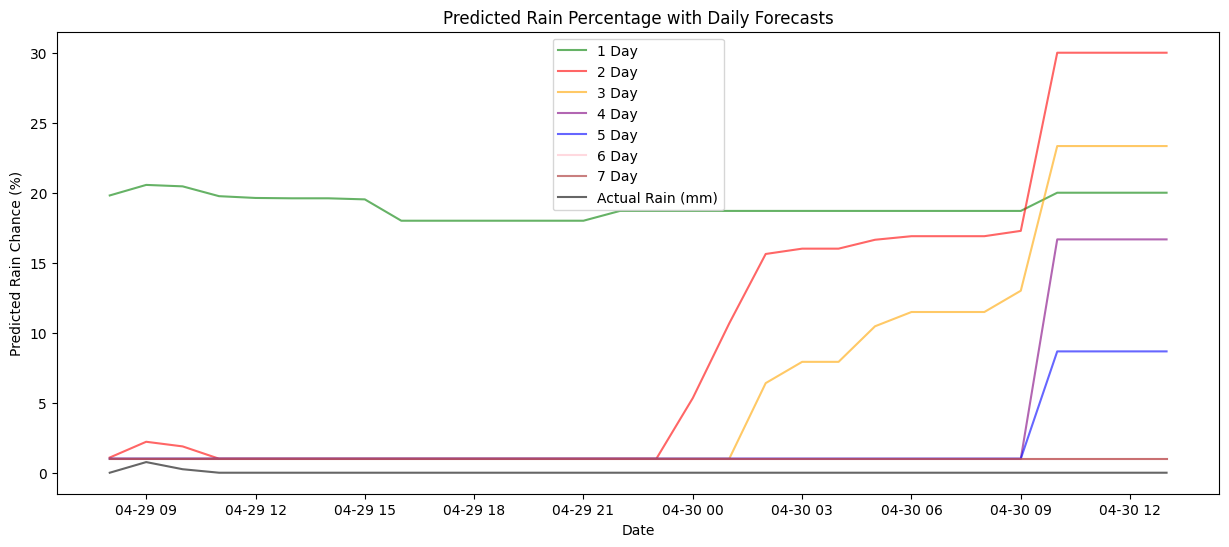

In [64]:
data_chunk = data.iloc[55400:55430]

plt.figure(figsize=(15, 6))

# Plotting the Predicted Rain Chance Percentages for each day
colors = ['green', 'red', 'orange', 'purple', 'blue', 'pink', 'brown']
labels = [f'{i} Day' for i in range(1, 8)]

# Iterate through each day to plot its predicted percentage
for i in range(1, 8):
    plt.plot(data_chunk.index, data_chunk[f'Rain_Chance_Percentage_{i}d'], label=labels[i-1], color=colors[i-1], alpha=0.6)

# Plot actual rain mm
plt.plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rain (mm)', color='black', alpha=0.6)

# Setting labels and title
plt.xlabel('Date')
plt.ylabel('Predicted Rain Chance (%)')
plt.title('Predicted Rain Percentage with Daily Forecasts')

# Display legend
plt.legend()

plt.show()

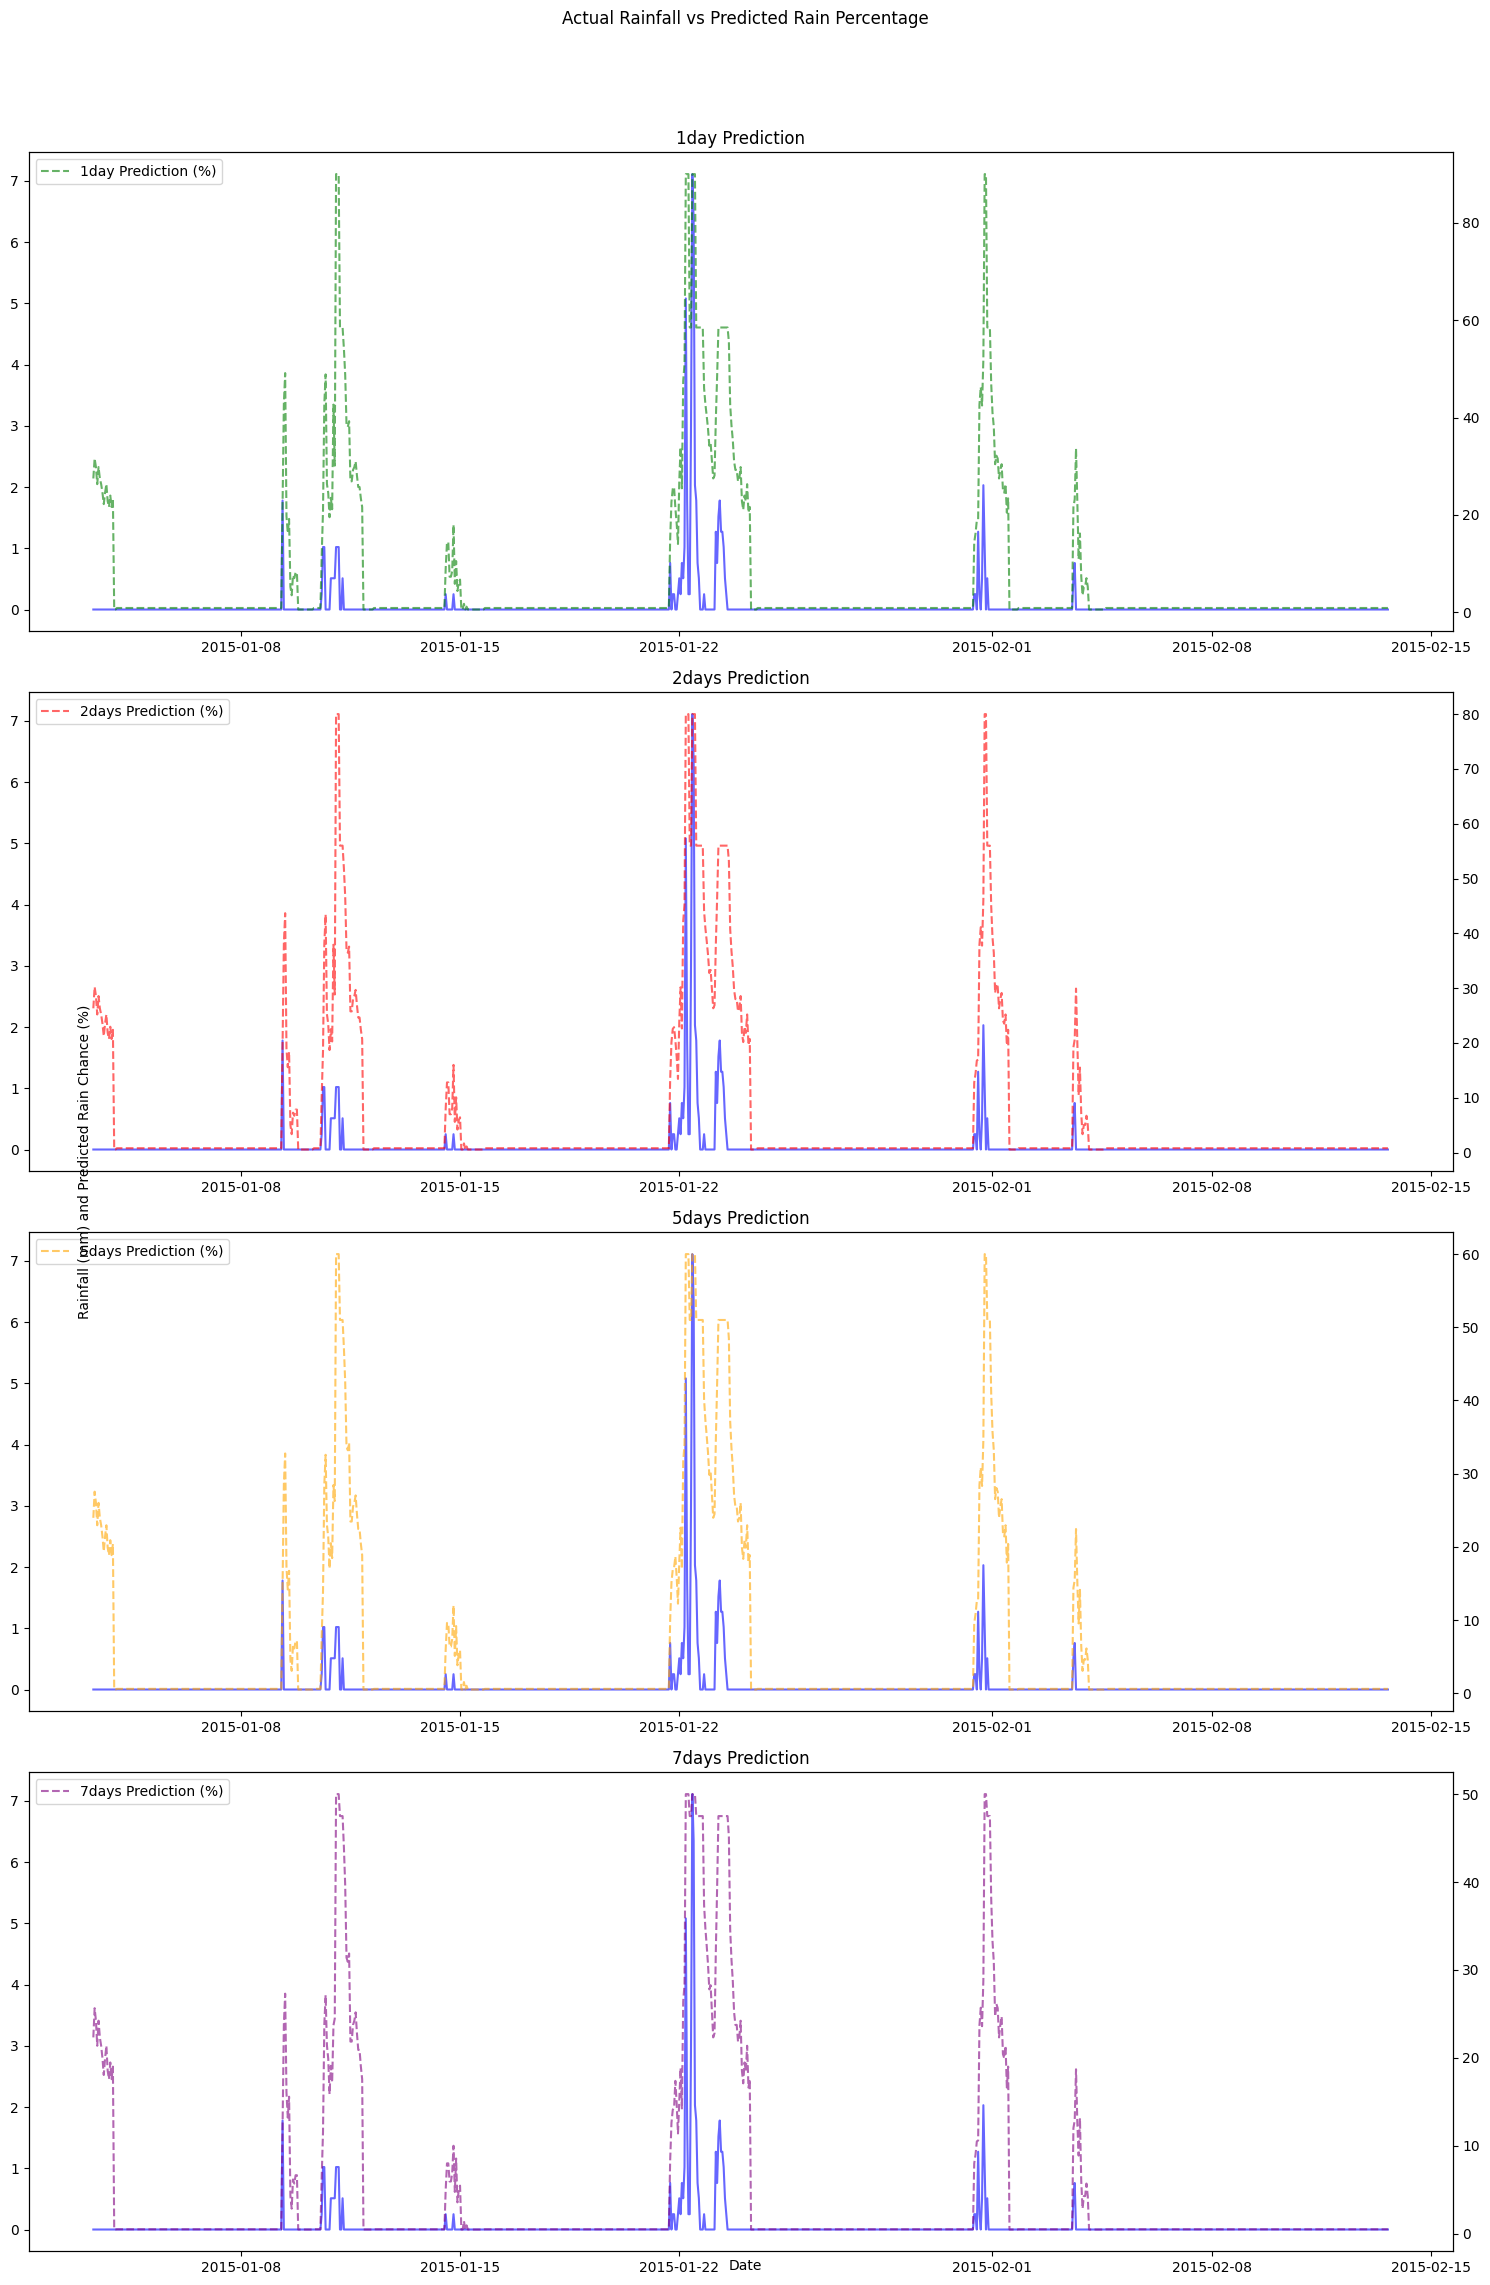

In [65]:


data_chunk = data.iloc[7:1000]
fig, axs = plt.subplots(4, 1, figsize=(15, 24))

# Setting common labels and title
fig.text(0.5, 0.04, 'Date', ha='center', va='center')
fig.text(0.06, 0.5, 'Rainfall (mm) and Predicted Rain Chance (%)', ha='center', va='center', rotation='vertical')
fig.suptitle('Actual Rainfall vs Predicted Rain Percentage')

# Actual Rainfall vs 1hr Prediction
axs[0].plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax1 = axs[0].twinx()
ax1.plot(data_chunk.index, data_chunk['Predict_1days_Percentage'], label='1day Prediction (%)', color='green', alpha=0.6, linestyle='--')
axs[0].set_title('1day Prediction')

# Actual Rainfall vs 2days Prediction
axs[1].plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax2 = axs[1].twinx()
ax2.plot(data_chunk.index, data_chunk['Predict_2days_Percentage'], label='2days Prediction (%)', color='red', alpha=0.6, linestyle='--')
axs[1].set_title('2days Prediction')

# Actual Rainfall vs 5days Prediction
axs[2].plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax3 = axs[2].twinx()
ax3.plot(data_chunk.index, data_chunk['Predict_5days_Percentage'], label='5days Prediction (%)', color='orange', alpha=0.6, linestyle='--')
axs[2].set_title('5days Prediction')

# Actual Rainfall vs 7days Prediction
axs[3].plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)
ax4 = axs[3].twinx()
ax4.plot(data_chunk.index, data_chunk['Predict_7days_Percentage'], label='7days Prediction (%)', color='purple', alpha=0.6, linestyle='--')
axs[3].set_title('7days Prediction')


ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax3.legend(loc='upper left')
ax4.legend(loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


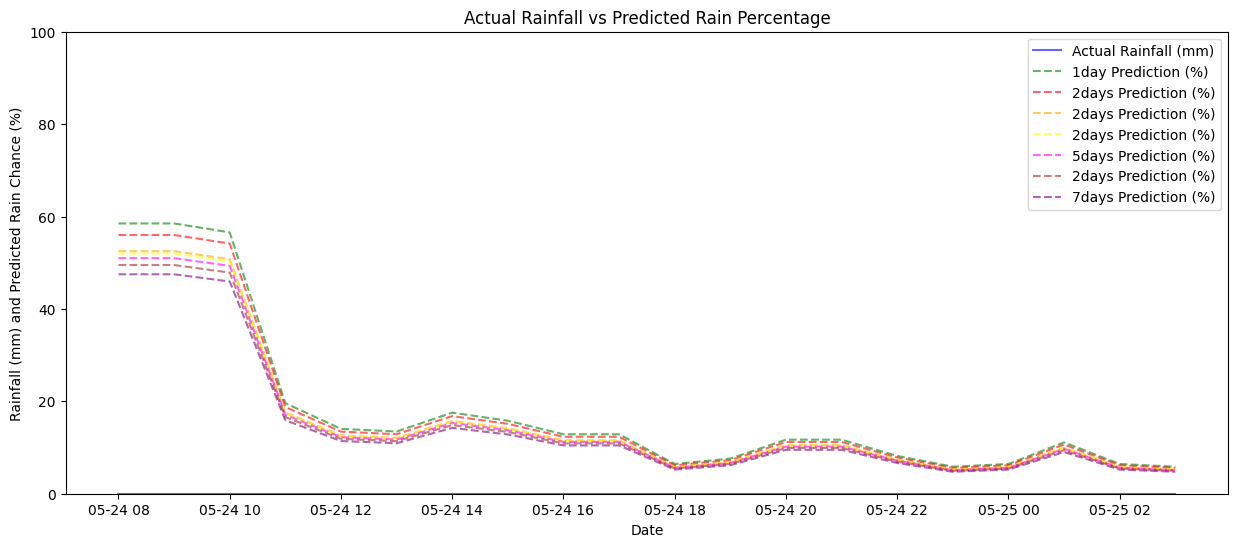

In [66]:
#max_percentage = data_chunk[['Predict_1days_Percentage', 'Predict_2days_Percentage', 'Predict_5days_Percentage', 'Predict_7days_Percentage']].max().max()

data_chunk = data.iloc[56000:56020]

plt.figure(figsize=(15, 6))

# Plotting Actual Rainfall
plt.plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)

# Plotting Predicted Rain Chance Percentages
plt.plot(data_chunk.index, data_chunk['Predict_1days_Percentage'], label='1day Prediction (%)', color='green', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_2days_Percentage'], label='2days Prediction (%)', color='red', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_3days_Percentage'], label='2days Prediction (%)', color='orange', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_4days_Percentage'], label='2days Prediction (%)', color='yellow', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_5days_Percentage'], label='5days Prediction (%)', color='magenta', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_6days_Percentage'], label='2days Prediction (%)', color='brown', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predict_7days_Percentage'], label='7days Prediction (%)', color='purple', alpha=0.6, linestyle='--')

# Setting labels and title
plt.xlabel('Date')
plt.ylabel('Rainfall (mm) and Predicted Rain Chance (%)')
plt.title('Actual Rainfall vs Predicted Rain Percentage')

# Using the maximum predicted rain chance percentage as the y-axis limit for percentages
plt.ylim([0, 100])

# Display legend
plt.legend()

plt.show()

In [67]:
print(data['Predict_5days_Percentage'])


2015-01-03 00:00:00    60.0
2015-01-03 01:00:00    60.0
2015-01-03 02:00:00    51.0
2015-01-03 03:00:00    51.0
2015-01-03 04:00:00    51.0
                       ... 
2021-08-31 20:00:00     0.6
2021-08-31 21:00:00     0.6
2021-08-31 22:00:00     0.6
2021-08-31 23:00:00     0.6
2021-09-01 00:00:00     0.6
Name: Predict_5days_Percentage, Length: 58393, dtype: float64


##Normal Distribution Error

Add normal distribution error of 0.5 to all predicted value columns


In [68]:
# Define the standard deviation for the normally distributed error
std_dev = 0.5

# Add the normally distributed error to each prediction column
for column in ['Predict_1days_Percentage',
               'Predict_2days_Percentage','Predict_3days_Percentage', 'Predict_4days_Percentage','Predict_5days_Percentage', 'Predict_6days_Percentage',
               'Predict_7days_Percentage']:
    # Generate normally distributed errors
    error = np.random.normal(loc=0, scale=std_dev, size=len(data))

    # Apply the error and enforce a minimum value of 1%
    data[column] = data[column] + error
    data[column] = data[column].clip(lower=1)

# Ensure that the predictions do not exceed 100%
data[['Predict_1days_Percentage',
               'Predict_2days_Percentage','Predict_3days_Percentage', 'Predict_4days_Percentage','Predict_5days_Percentage', 'Predict_6days_Percentage',
               'Predict_7days_Percentage']] = data[['Predict_1days_Percentage',
               'Predict_2days_Percentage','Predict_3days_Percentage', 'Predict_4days_Percentage','Predict_5days_Percentage', 'Predict_6days_Percentage',
               'Predict_7days_Percentage']].clip(upper=100)

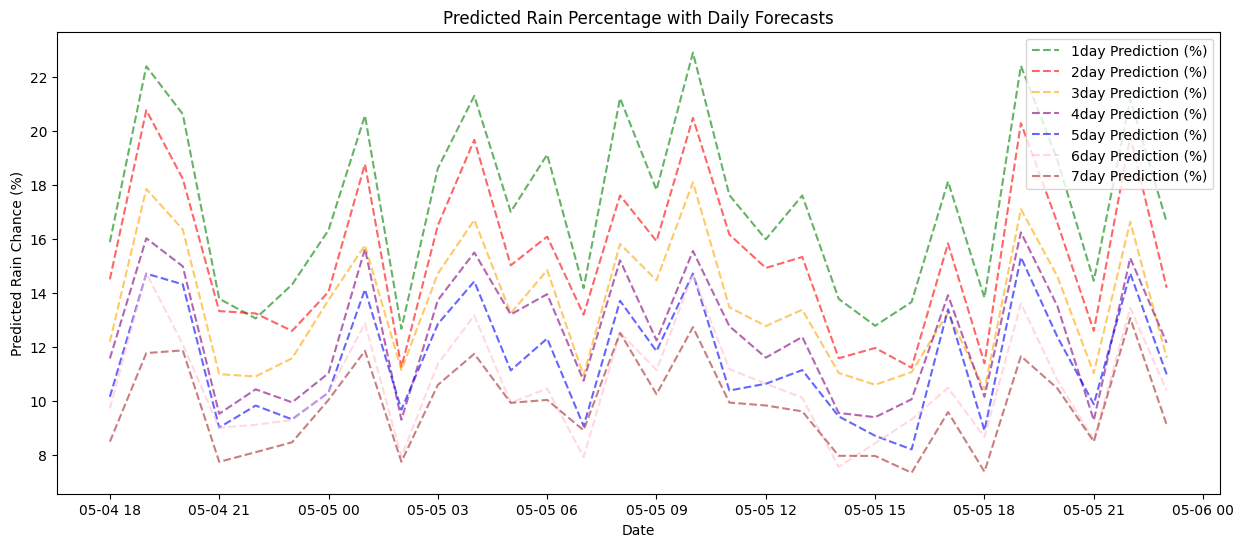

In [69]:
data_chunk = data.iloc[55530:55560]
plt.figure(figsize=(15, 6))

# Plotting the Predicted Rain Chance Percentages for each day
colors = ['green', 'red', 'orange', 'purple', 'blue', 'pink', 'brown']
labels = [f'{i}day Prediction (%)' for i in range(1, 8)]

# Iterate through each day to plot its predicted percentage
for i in range(7):
    plt.plot(data_chunk.index, data_chunk[f'Predict_{i+1}days_Percentage'], label=labels[i], color=colors[i], alpha=0.6, linestyle='--')

# Setting labels and title
plt.xlabel('Date')
plt.ylabel('Predicted Rain Chance (%)')
plt.title('Predicted Rain Percentage with Daily Forecasts')

# Display legend
plt.legend()

plt.show()


<Figure size 1500x2400 with 0 Axes>

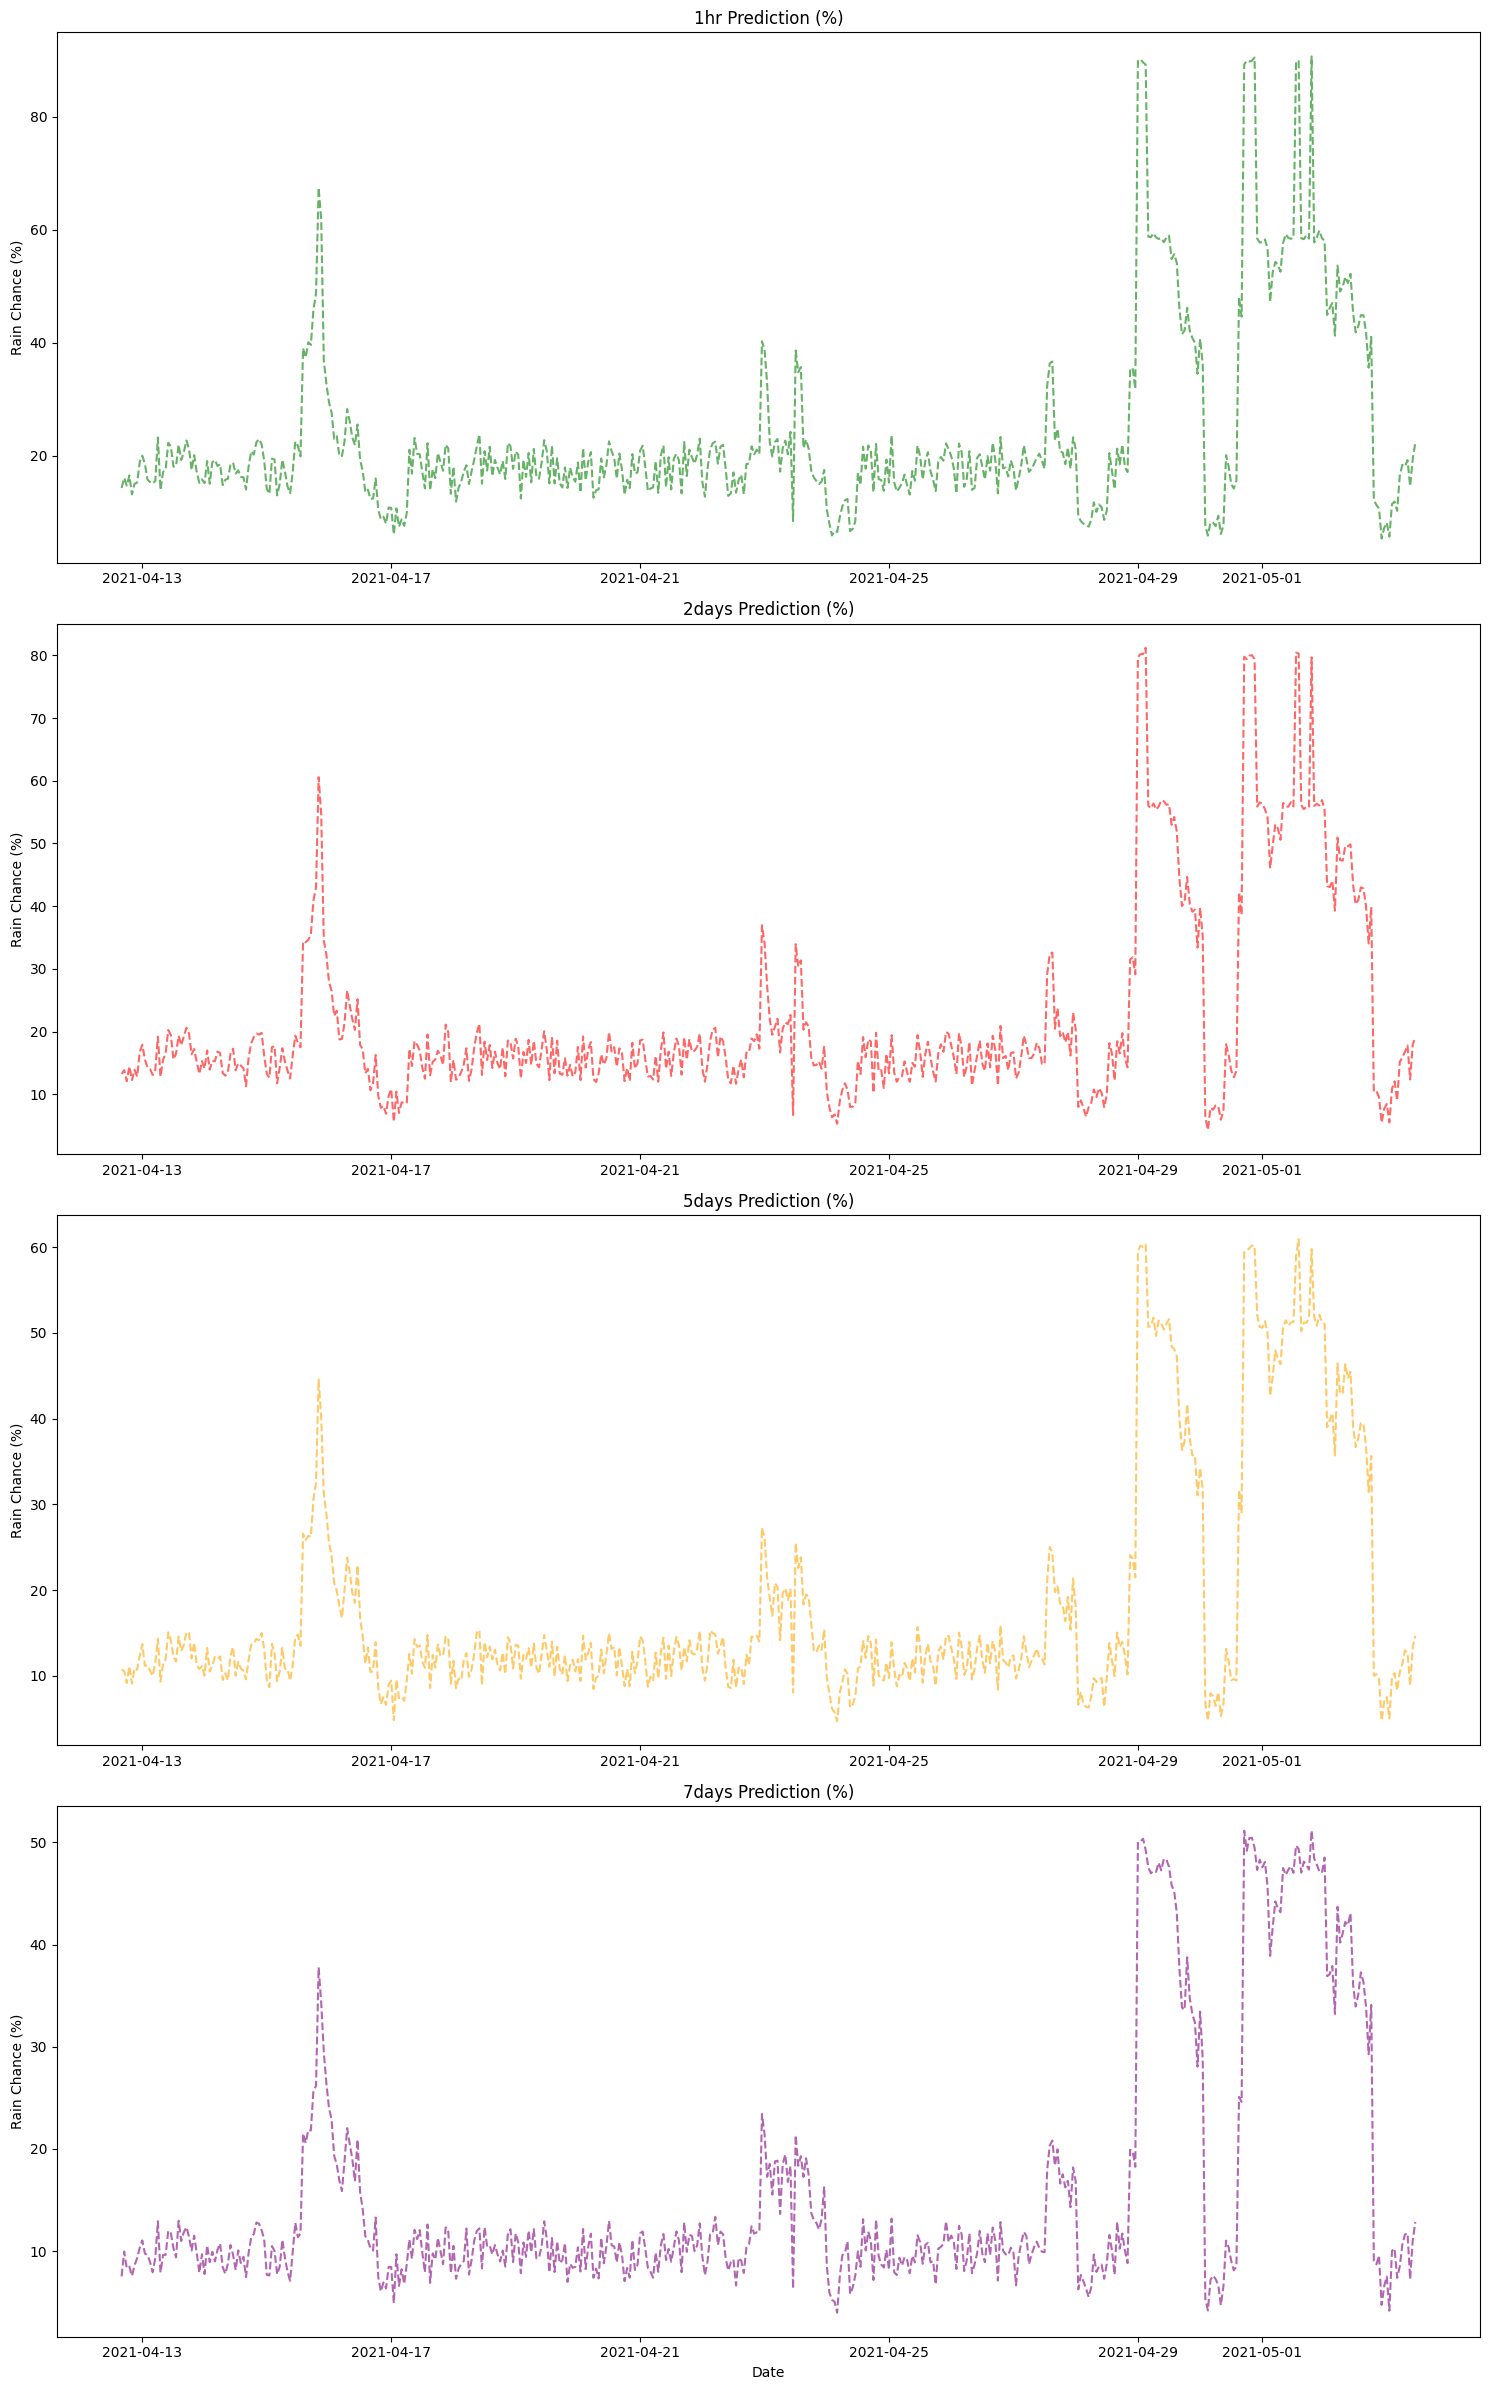

In [70]:
data_chunk = data.iloc[55000:55500]
plt.figure(figsize=(15, 24))

# Creating a 4x1 subplot
fig, axs = plt.subplots(4, 1, figsize=(15, 24))

# 1hr Prediction
axs[0].plot(data_chunk.index, data_chunk['Predict_1days_Percentage'], 'g--', alpha=0.6)
axs[0].set_title('1hr Prediction (%)')
axs[0].set_ylabel('Rain Chance (%)')

# 2days Prediction
axs[1].plot(data_chunk.index, data_chunk['Predict_2days_Percentage'], 'r--', alpha=0.6)
axs[1].set_title('2days Prediction (%)')
axs[1].set_ylabel('Rain Chance (%)')

# 5days Prediction
axs[2].plot(data_chunk.index, data_chunk['Predict_5days_Percentage'], 'orange', linestyle='--', alpha=0.6)
axs[2].set_title('5days Prediction (%)')
axs[2].set_ylabel('Rain Chance (%)')

# 7days Prediction
axs[3].plot(data_chunk.index, data_chunk['Predict_7days_Percentage'], 'purple', linestyle='--', alpha=0.6)
axs[3].set_title('7days Prediction (%)')
axs[3].set_xlabel('Date')
axs[3].set_ylabel('Rain Chance (%)')

# Adjust layout to not overlap
plt.tight_layout()

plt.show()

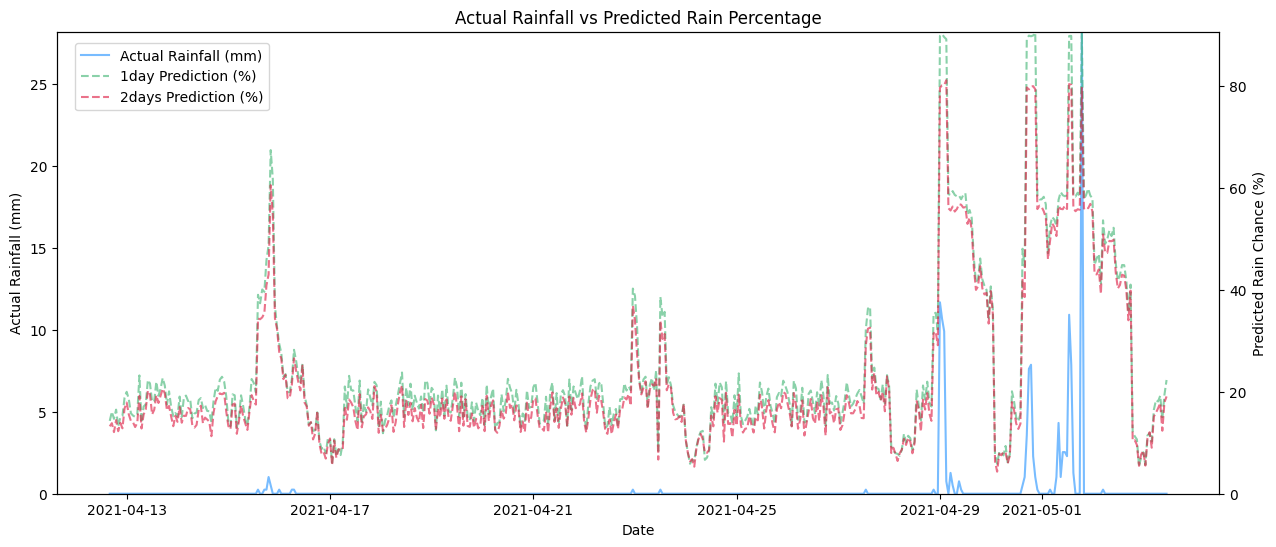

In [71]:
# Assuming data_chunk is already defined and has the required data
max_percentage = data_chunk[['Predict_1days_Percentage', 'Predict_2days_Percentage']].max().max()
max_rainfall = data_chunk['Ppt'].max()

# Set a common start for the y-axes
common_y_start = 0

fig, ax1 = plt.subplots(figsize=(15, 6))

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plotting Actual Rainfall on the first y-axis (ax1)
ax1.plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='dodgerblue', alpha=0.6)
ax1.set_ylabel('Actual Rainfall (mm)')
ax1.tick_params(axis='y')
ax1.set_ylim([common_y_start, max_rainfall])  # Match zero on both y-axes

# Plotting Predicted Rain Chance Percentages on the second y-axis (ax2)
ax2.plot(data_chunk.index, data_chunk['Predict_1days_Percentage'], label='1day Prediction (%)', color='mediumseagreen', alpha=0.6, linestyle='--')
ax2.plot(data_chunk.index, data_chunk['Predict_2days_Percentage'], label='2days Prediction (%)', color='crimson', alpha=0.6, linestyle='--')
ax2.set_ylabel('Predicted Rain Chance (%)')
ax2.tick_params(axis='y')
ax2.set_ylim([common_y_start, max_percentage])  # Match zero on both y-axes

# Title and legend
ax1.set_xlabel('Date')
ax1.set_title('Actual Rainfall vs Predicted Rain Percentage')
fig.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), bbox_transform=ax1.transAxes)

# Save the figure as a PDF
plt.savefig("timeseries.pdf", format='pdf')


#Prediction Error

Create a method to caclulate the MSE for the different predicated rain values and then also calcualte the MAE and MSE for the predicted percentages from using the actual eprcentage as a base for comparison

In [72]:
#prediction error MSE from predicted rain values to actual rain sums
data['MSE_1h'] = ((data['Predicted_Rain_Next_Hour_1h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_3h'] = ((data['Predicted_Rain_Next_Hour_3h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_6h'] = ((data['Predicted_Rain_Next_Hour_6h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_12h'] = ((data['Predicted_Rain_Next_Hour_12h'] - data['Actual_Rain_Next_Hour']) ** 2)
data['MSE_24h'] = ((data['Predicted_Rain_Next_Hour_24h'] - data['Actual_Rain_Next_Hour']) ** 2)

In [73]:
# Define the columns to calculate MSE
predicted_columns = [
    'Predicted_Rain_Next_Hour_1h',
    'Predicted_Rain_Next_Hour_3h',
    'Predicted_Rain_Next_Hour_6h',
    'Predicted_Rain_Next_Hour_12h',
    'Predicted_Rain_Next_Hour_24h',
]

# Calculate MSE for each prediction column
mse_values = {}
for col in predicted_columns:
    mse = ((data[col] - data['Actual_Rain_Next_Hour']) ** 2).mean()
    mse_values[col] = mse

# Printing MSE values
for col, mse in mse_values.items():
    print(f"MSE for {col}: {mse}")

MSE for Predicted_Rain_Next_Hour_1h: 1.5827927558569665
MSE for Predicted_Rain_Next_Hour_3h: 4.811967798671049
MSE for Predicted_Rain_Next_Hour_6h: 11.650908401835869
MSE for Predicted_Rain_Next_Hour_12h: 28.126193228524468
MSE for Predicted_Rain_Next_Hour_24h: 65.72545084943138


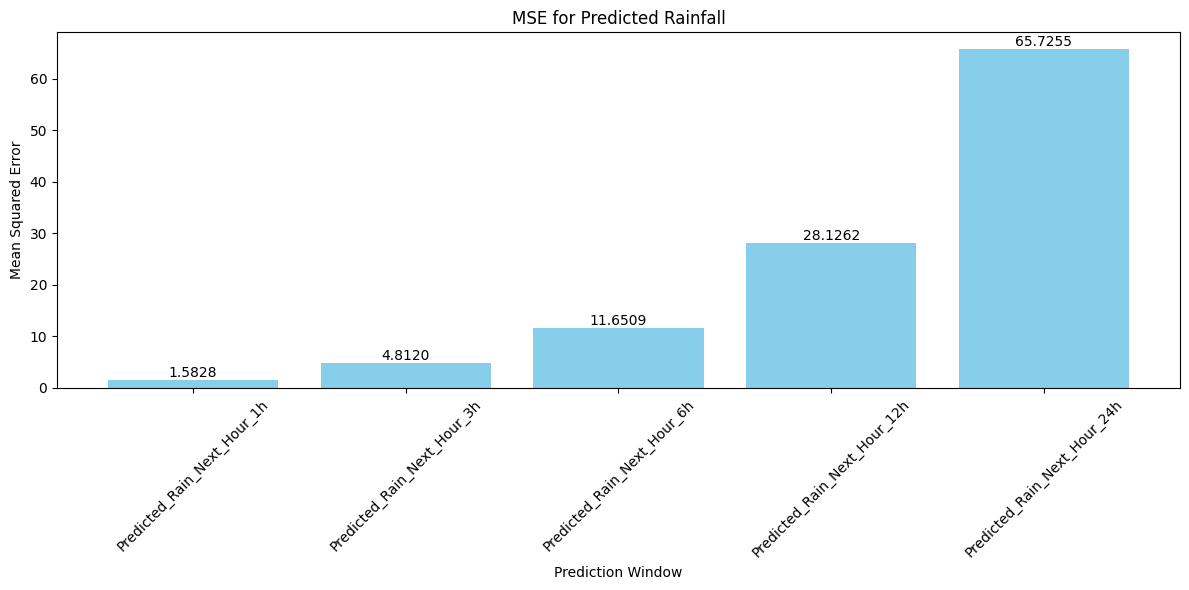

In [74]:

# Converting the MSE values dictionary to lists for plotting
columns = list(mse_values.keys())
mse_scores = list(mse_values.values())

plt.figure(figsize=(12, 6))
plt.bar(columns, mse_scores, color='skyblue')
plt.xlabel('Prediction Window')
plt.ylabel('Mean Squared Error')
plt.title('MSE for Predicted Rainfall')
plt.xticks(rotation=45)
plt.tight_layout()

#  MSE values on top of each bar for clarity
for i, mse in enumerate(mse_scores):
    plt.text(i, mse, f"{mse:.4f}", ha='center', va='bottom')
plt.savefig("timeseriesmse.pdf", format='pdf')
plt.show()

In [75]:
# Calculate MAE and MSE
mae = mean_absolute_error(data['Actual_Rain_Chance'], data['Rain_Chance_Percentage'])
mse = mean_squared_error(data['Actual_Rain_Chance'], data['Rain_Chance_Percentage'])

# Calculate MAE as a percentage of the average actual rain
average_actual_rain = data['Actual_Rain_Chance'].mean()
mae_percentage = (mae / average_actual_rain) * 100

#Print values
print('mae', mae)
print('mse', mse)

mae 11.49287757094172
mse 498.8404469713835


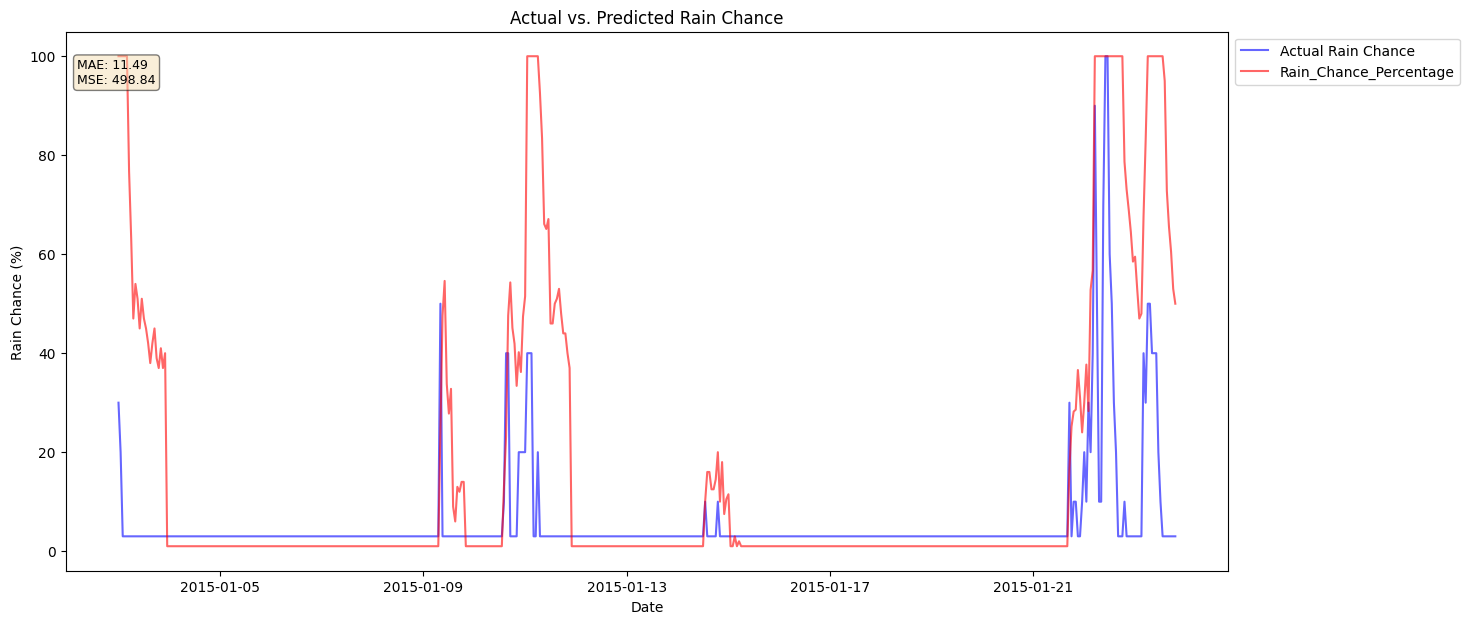

In [76]:
data_chunk = data.iloc[:500]

plt.figure(figsize=(15, 7))

# Plotting Actual and Predicted Rain
plt.plot(data_chunk.index, data_chunk['Actual_Rain_Chance'], label='Actual Rain Chance', color='blue', alpha=0.6)
plt.plot(data_chunk.index, data_chunk['Rain_Chance_Percentage'], label='Rain_Chance_Percentage', color='red', alpha=0.6)

# MAE and MSE
plt.text(0.01, 0.95, f'MAE: {mae:.2f}\nMSE: {mse:.2f}', transform=plt.gca().transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Setting the labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Rain Chance (%)')
plt.title('Actual vs. Predicted Rain Chance')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

#Export to CSV

In [77]:
print(data.columns)

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Ppt.1', 'Tair', 'RH', 'Srad', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'Sum_Rain_1h', 'Sum_Rain_3h', 'Sum_Rain_6h',
       'Sum_Rain_12h', 'Sum_Rain_24h', 'Sum_Rain_1h_Shifted',
       'Sum_Rain_3h_Shifted', 'Sum_Rain_6h_Shifted', 'Sum_Rain_12h_Shifted',
       'Sum_Rain_24h_Shifted', 'Actual_Rain_Next_Hour',
       'Predicted_Rain_Next_Hour_1h', 'Predicted_Rain_Next_Hour_3h',
       'Predicted_Rain_Next_Hour_6h', 'Predicted_Rain_Next_Hour_12h',
       'Predicted_Rain_Next_Hour_24h', 'Rain_Chance_Percentage_1d',
       'Rain_Chance_Percentage_2d', 'Rain_Chance_Percentage_3d',
       'Rain_Chance_Percentage_4d', 'Rain_Chance_Percentage_5d',
       'Rain_Chance_Percentage_6d', 'Rain_Chance_Percentage_7d',
       'Rain_Chance_Percentage', 'Predict_1days_Percentage',
       'Predict_2days_Percentage', 'Predict_3days_Percentage',
       'Predict_4days_Percentage', 'Predict_5da

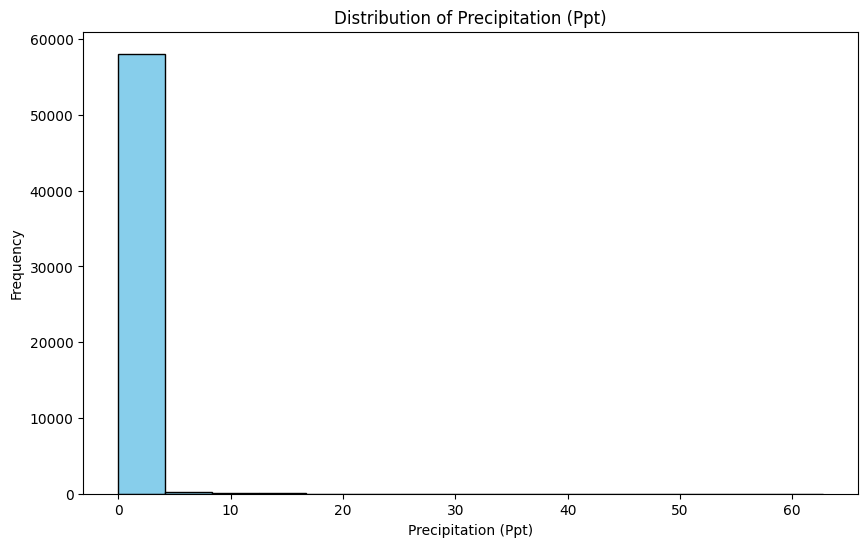

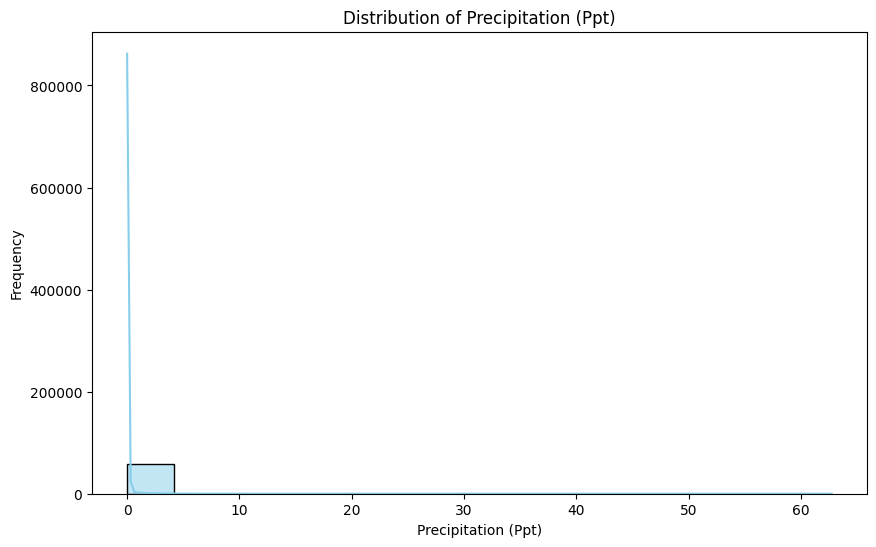

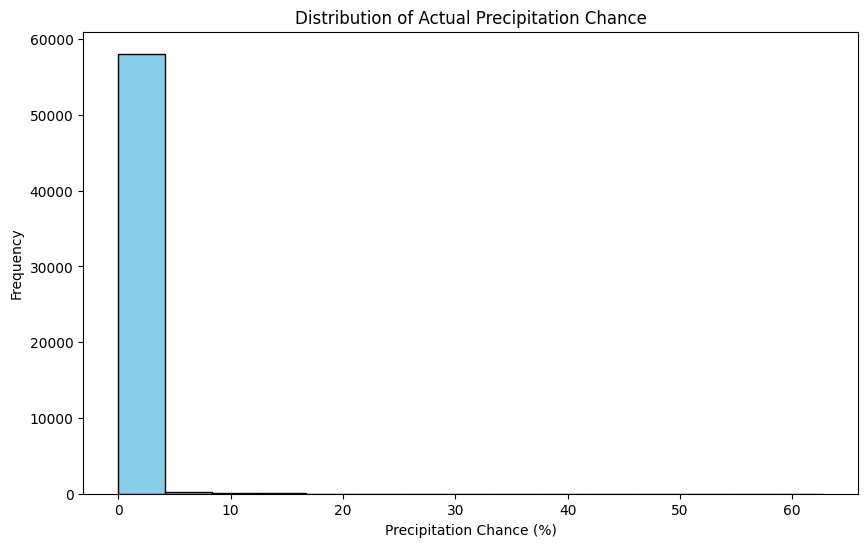

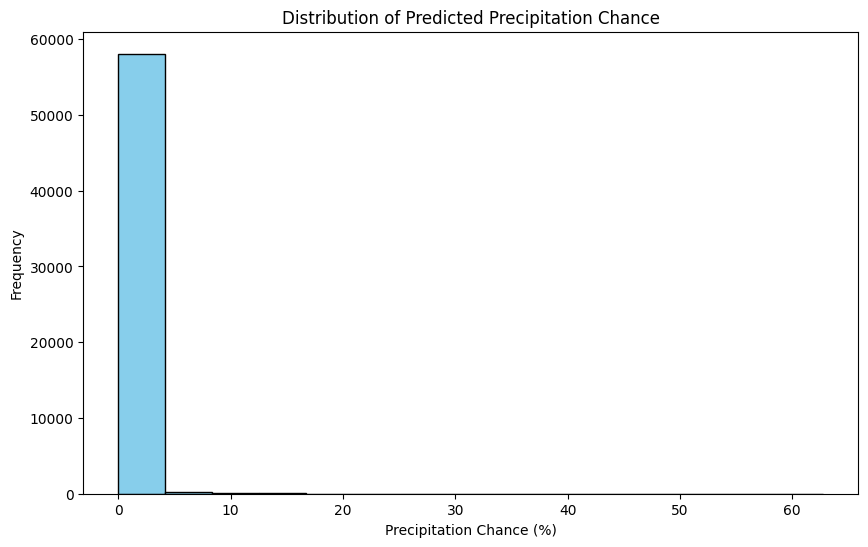

In [78]:
plt.figure(figsize=(10, 6))
plt.hist(data['Ppt'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Precipitation (Ppt)')
plt.xlabel('Precipitation (Ppt)')
plt.ylabel('Frequency')
plt.show()

# Using seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data['Ppt'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Precipitation (Ppt)')
plt.xlabel('Precipitation (Ppt)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(data['Ppt'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Actual Precipitation Chance')
plt.xlabel('Precipitation Chance (%)')
plt.ylabel('Frequency')
plt.show()

# Using seaborn
plt.figure(figsize=(10, 6))
plt.hist(data['Ppt'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Predicted Precipitation Chance')
plt.xlabel('Precipitation Chance (%)')
plt.ylabel('Frequency')
plt.show()

In [79]:
columns_to_drop = [
    'Actual_Rain_Next_Hour',
    'Actual_Rain_Chance',
    'Sum_Rain_1h_Shifted',
    'Sum_Rain_3h_Shifted',
    'Sum_Rain_6h_Shifted',
    'Sum_Rain_12h_Shifted',
    'Sum_Rain_24h_Shifted',
    # 'Predicted_Rain_Next_Hour_3h',
    # 'Predicted_Rain_Next_Hour_6h',
    # 'Predicted_Rain_Next_Hour_12h',
    # 'Predicted_Rain_Next_Hour_24h',
    # 'Rain_Chance_Percentage',
    # 'Predict_1day_Percentage',
    # 'Predicted_Rain_Next_Hour_1h',
    'MSE_1h',
    'MSE_3h',
    'MSE_6h',
    'MSE_12h',
    'MSE_24h'
]

# Drop the specified columns from the DataFrame
data_cleaned = data.drop(columns=columns_to_drop, errors='ignore')

In [80]:
print(data_cleaned.columns)

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Ppt.1', 'Tair', 'RH', 'Srad', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'Sum_Rain_1h', 'Sum_Rain_3h', 'Sum_Rain_6h',
       'Sum_Rain_12h', 'Sum_Rain_24h', 'Predicted_Rain_Next_Hour_1h',
       'Predicted_Rain_Next_Hour_3h', 'Predicted_Rain_Next_Hour_6h',
       'Predicted_Rain_Next_Hour_12h', 'Predicted_Rain_Next_Hour_24h',
       'Rain_Chance_Percentage_1d', 'Rain_Chance_Percentage_2d',
       'Rain_Chance_Percentage_3d', 'Rain_Chance_Percentage_4d',
       'Rain_Chance_Percentage_5d', 'Rain_Chance_Percentage_6d',
       'Rain_Chance_Percentage_7d', 'Rain_Chance_Percentage',
       'Predict_1days_Percentage', 'Predict_2days_Percentage',
       'Predict_3days_Percentage', 'Predict_4days_Percentage',
       'Predict_5days_Percentage', 'Predict_6days_Percentage',
       'Predict_7days_Percentage'],
      dtype='object')


In [81]:
data_cleaned.to_csv('./Station3_precipitation_chance.csv', index=True)

In [ ]:
from google.colab import files
files.download('/content/cleaned_data1-7-4.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>